# N-1 Teacher action space — picking `k`

Exploratory analysis of the N-1 Teacher experience collected on **IEEE-36** (`l2rpn_wcci_2020`)
and **IEEE-118** (`l2rpn_wcci_2022`), to decide the `--top-k` handed to

```
python experiments/build_action_space.py aggregate --grid <grid> --top-k <k> --out <json>
```

**Run this in the `curriculum` conda env** (it needs `grid2op`, `lightsim2grid` and
`curriculumagent`):

```bash
module load devel/miniforge && eval "$(conda shell.bash hook)" && conda activate curriculum
jupyter lab experiments/teacher_action_space_analysis.ipynb
```

**Input:** `results/teacher/aggregated/experience_<grid>.csv`, written by
`results/teacher/aggregate_shards.py`. Re-run that script to refresh as more SLURM shards land.

**These numbers are preliminary.** At the time of writing the case118 array is ~99% complete but
the case36 array is only ~74% through, so case36's ranking will keep moving. §7 quantifies how
much.

In [1]:
from __future__ import annotations

import base64
import json
import sys
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_root(start: Path) -> Path:
    """Walk up from `start` until the repo root (the dir holding src/action_space_generation)."""
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "action_space_generation").is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {start}")


ROOT = find_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))

AGGREGATED = ROOT / "results" / "teacher" / "aggregated"

GRIDS = ["case36", "case118"]
ENV_NAMES = {"case36": "l2rpn_wcci_2020_train", "case118": "l2rpn_wcci_2022_train"}
ACTION_SPACE_DIRS = {
    "case36": ROOT / "data" / "action_spaces" / "l2rpn_wcci_2020",
    "case118": ROOT / "data" / "action_spaces" / "l2rpn_wcci_2022",
}
# From results/teacher/SUMMARY.md §2 — the contingencies the teacher searched against.
LINES_TO_ATTACK = {
    "case36": [20, 13, 39, 33, 35, 32, 11, 34, 23, 22],
    "case118": [146, 136, 147, 156, 135, 149, 72, 20, 154, 12],
}

print(f"repo root: {ROOT}")

repo root: /pfs/data6/home/ka/ka_iai/ka_hw6998/dev/NRI-for-explainable-RL-in-Power-Grids


In [2]:
# ── Plot style: recessive axes, ink-coloured text, two validated categorical hues ──────────
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8983", "#e8e7e3"
SERIES = {"case36": "#2a78d6", "case118": "#eb6834"}  # categorical slots 1 and 2
SEQUENTIAL = "#2a78d6"  # single-hue ramp base for magnitude bars

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2.0,
    "font.size": 9,
})


def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Apply the shared chart furniture: left-aligned title, recessive grid behind the marks."""
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis=grid_axis)
    ax.set_axisbelow(True)
    return ax

## 1. Load the aggregated experience

One row per teacher interaction where the N-1 search found an action passing both of its filters.
Columns come from `curriculumagent.teacher.submodule.common.save_sample_new`:

| column | meaning |
|---|---|
| `rho_max_old` | worst line loading **before** the action (`obs.rho.max()`) |
| `rho_max_new` | worst line loading **after** it |
| `rho_improvement` | the search's ranking score for the winner, `old_max_rho - new_max_rho` (**absolute**, not a percentage) |
| `best_action` | the chosen action, `base64(zlib(action._set_topo_vect))` |
| `top_0_action`, `top_0_ri` | the top-`k` candidate list; these runs used `top_k=1`, so `top_0_action == best_action` on every row |
| `grid`, `shard`, `chronic_first`, `chronic_last` | provenance added by `aggregate_shards.py` |
| `good` | would `filter_good_experience` keep this row (`rho_improvement > 0.02`) |

In [3]:
raw = {grid: pd.read_csv(AGGREGATED / f"experience_{grid}.csv") for grid in GRIDS}

overview = pd.DataFrame([
    {
        "grid": grid,
        "rows": len(data),
        "good rows": int(data["good"].sum()),
        "dropped by filter": int((~data["good"]).sum()),
        "shards": data["shard"].nunique(),
        "chronics covered": data["chronic_last"].max(),
        "unique actions (all)": data["best_action"].nunique(),
        "unique actions (good)": data.loc[data["good"], "best_action"].nunique(),
    }
    for grid, data in raw.items()
]).set_index("grid")
overview.T

grid,case36,case118
rows,11363,3528
good rows,9309,2826
dropped by filter,2054,702
shards,648,617
chronics covered,2034,1496
unique actions (all),3885,2019
unique actions (good),3511,1721


In [4]:
# Sanity checks on the column semantics, so later cells can rely on them.
for grid, data in raw.items():
    residual = (data["rho_max_old"] - data["rho_max_new"] - data["rho_improvement"]).abs().max()
    print(f"{grid}:")
    print(f"  max |rho_max_old - rho_max_new - rho_improvement| = {residual:.2e}"
          "  (so rho_improvement is just the difference of the two rho columns)")
    print(f"  rows where top_0_action != best_action: {(data['best_action'] != data['top_0_action']).sum()}")
    print(f"  encoded do-nothing rows (best_action == '0'): {(data['best_action'] == '0').sum()}")
    print(f"  rho_max_old range: {data['rho_max_old'].min():.3f} .. {data['rho_max_old'].max():.3f}"
          f"  (mean {data['rho_max_old'].mean():.3f})")
    print(f"  exact duplicate rows: {data.duplicated(subset=['rho_max_old', 'rho_max_new', 'best_action', 'shard']).sum()}")

case36:
  max |rho_max_old - rho_max_new - rho_improvement| = 7.00e-08  (so rho_improvement is just the difference of the two rho columns)
  rows where top_0_action != best_action: 0
  encoded do-nothing rows (best_action == '0'): 0
  rho_max_old range: 0.950 .. 1.000  (mean 0.968)
  exact duplicate rows: 0
case118:
  max |rho_max_old - rho_max_new - rho_improvement| = 1.00e-07  (so rho_improvement is just the difference of the two rho columns)
  rows where top_0_action != best_action: 0
  encoded do-nothing rows (best_action == '0'): 0
  rho_max_old range: 0.950 .. 1.000  (mean 0.967)
  exact duplicate rows: 42


## 2. What the `rho_improvement > 0.02` filter does

`load_experience` applies `filter_good_experience`, which keeps only rows whose action pulled the
worst line loading down by more than 0.02 in absolute rho. The threshold is hard-coded upstream;
this sweep shows how sensitive the surviving action set is to it, which is worth knowing before
treating 0.02 as a given.

,case36 rows,case118 rows,case36 actions,case118 actions
threshold,,,,
0.00,10341,3378,3689,1955
0.01,9825,3169,3604,1870
0.02,9309,2826,3511,1721
0.05,7981,1954,3171,1316
0.10,5944,1092,2490,847
0.20,2579,324,1120,284


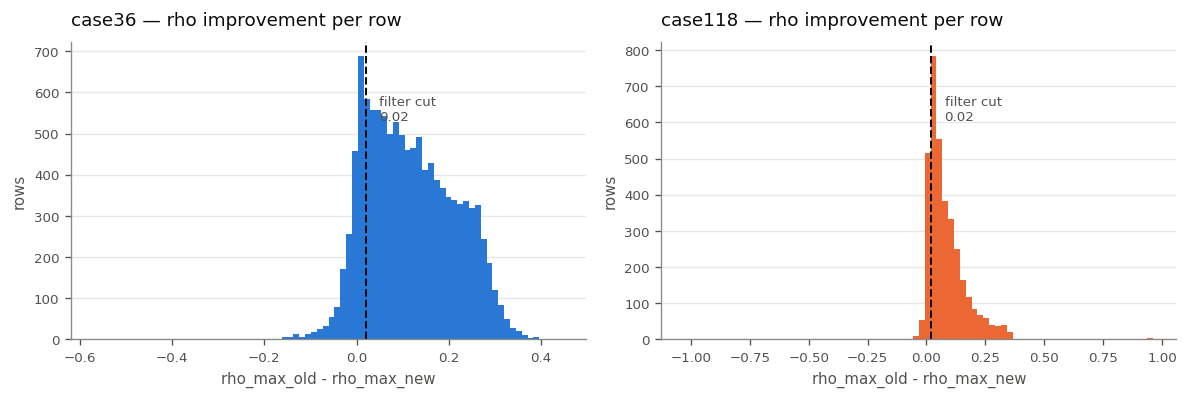

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

for ax, (grid, data) in zip(axes, raw.items()):
    ax.hist(data["rho_improvement"], bins=80, color=SERIES[grid], edgecolor="none")
    ax.axvline(0.02, color=INK, lw=1.2, ls="--")
    ax.annotate("filter cut\n0.02", xy=(0.02, ax.get_ylim()[1] * 0.82),
                xytext=(8, 0), textcoords="offset points", color=INK2, fontsize=8, va="top")
    style(ax, title=f"{grid} — rho improvement per row",
          xlabel="rho_max_old - rho_max_new", ylabel="rows")
fig.tight_layout()

sweep = pd.DataFrame([
    {
        "threshold": t,
        **{f"{grid} rows": int((data["rho_improvement"] > t).sum()) for grid, data in raw.items()},
        **{f"{grid} actions": int(data.loc[data["rho_improvement"] > t, "best_action"].nunique())
           for grid, data in raw.items()},
    }
    for t in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2]
]).set_index("threshold")
sweep

## 3. The knee: rank vs. times picked

`action_frequency` is `data["best_action"].value_counts()`, and `rank_actions_simple` keeps its
first `best_n` entries — so this curve *is* the selection rule. Plotted on a log y-axis because
the two grids differ by an order of magnitude in pick counts.

`knee_rank` is a Kneedle-style heuristic: normalise the log-frequency curve into the unit square
and take the rank furthest from the straight chord between its endpoints. It is a starting point
for the eye, not an answer — read it together with the coverage curve below.

grid,case36,case118
unique actions,3511,1721
top pick count,220,15
knee (heuristic),666,516
freq@25,36,7
freq@50,19,5
freq@100,12,4
freq@200,7,3
freq@400,4,2
cover@100,34%,22%
cover@200,44%,34%


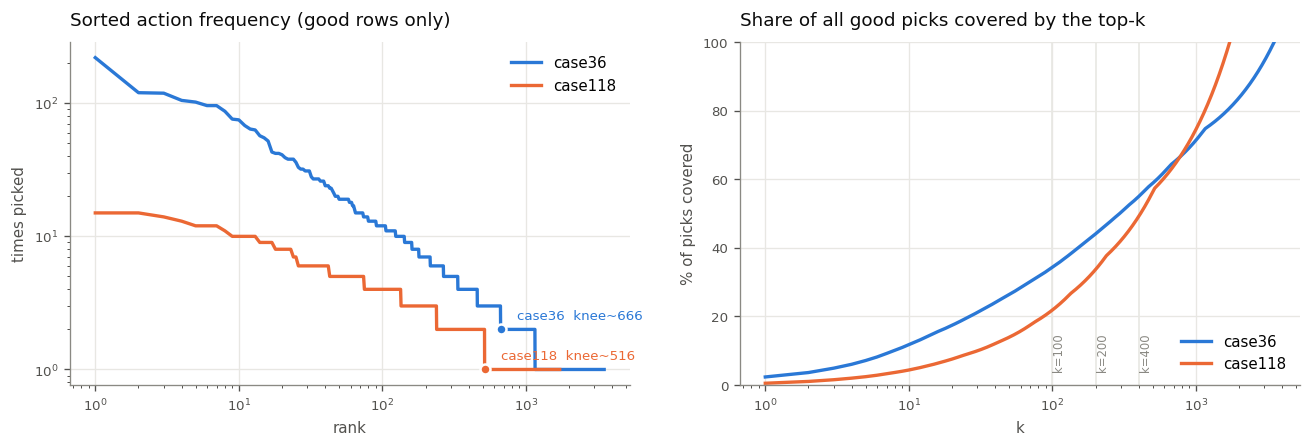

In [6]:
def frequency_curve(data: pd.DataFrame, good_only: bool = True) -> pd.Series:
    """Times each encoded action was picked, most-picked first — the tool's own ranking."""
    rows = data[data["good"]] if good_only else data
    return rows["best_action"].value_counts()


def knee_rank(frequencies) -> int:
    """Kneedle-style elbow of a decreasing curve: the rank furthest from the endpoint chord."""
    y = np.log10(np.asarray(frequencies, dtype=float))
    x = np.arange(1, len(y) + 1, dtype=float)
    if len(y) < 3 or y.max() == y.min():
        return len(y)
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    return int(np.argmax(np.abs(y_norm - (1.0 - x_norm))) + 1)


curves = {grid: frequency_curve(data) for grid, data in raw.items()}
knees = {grid: knee_rank(curve.values) for grid, curve in curves.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
for grid, curve in curves.items():
    ranks = np.arange(1, len(curve) + 1)
    ax.plot(ranks, curve.values, color=SERIES[grid], label=grid)
    ax.scatter([knees[grid]], [curve.values[knees[grid] - 1]], s=36, zorder=3,
               color=SERIES[grid], edgecolor="white", linewidth=1.5)
    ax.annotate(f"{grid}  knee~{knees[grid]}", xy=(knees[grid], curve.values[knees[grid] - 1]),
                xytext=(10, 6), textcoords="offset points", color=SERIES[grid], fontsize=8)
ax.set_yscale("log")
ax.set_xscale("log")
style(ax, title="Sorted action frequency (good rows only)",
      xlabel="rank", ylabel="times picked", grid_axis="both")
ax.legend(loc="upper right")

ax = axes[1]
for grid, curve in curves.items():
    share = np.cumsum(curve.values) / curve.values.sum() * 100
    ax.plot(np.arange(1, len(curve) + 1), share, color=SERIES[grid], label=grid)
for k in (100, 200, 400):
    ax.axvline(k, color=GRID, lw=1.0, zorder=0)
    ax.annotate(f"k={k}", xy=(k, 4), color=MUTED, fontsize=7, rotation=90, va="bottom")
ax.set_xscale("log")
ax.set_ylim(0, 100)
style(ax, title="Share of all good picks covered by the top-k",
      xlabel="k", ylabel="% of picks covered", grid_axis="both")
ax.legend(loc="lower right")
fig.tight_layout()

pd.DataFrame([
    {
        "grid": grid,
        "unique actions": len(curve),
        "top pick count": int(curve.iloc[0]),
        "knee (heuristic)": knees[grid],
        **{f"freq@{k}": (int(curve.iloc[k - 1]) if len(curve) >= k else None)
           for k in (25, 50, 100, 200, 400)},
        **{f"cover@{k}": (f"{curve.iloc[:k].sum() / curve.sum() * 100:.0f}%" if len(curve) >= k else None)
           for k in (100, 200, 400)},
    }
    for grid, curve in curves.items()
]).set_index("grid").T

## 4. Decode the actions

`EncodedTopologyAction.encode_action` is `base64(zlib(action._set_topo_vect, level=1))`, so the
string is a deterministic function of the topology vector and can be decoded back without an
environment. The environment is still needed for `sub_info`, which maps a position in the topology
vector to its substation.

Loading two Grid2Op environments takes a while; they are cached and reused.

In [7]:
import grid2op
from lightsim2grid import LightSimBackend

_ENV_CACHE: dict[str, object] = {}


def get_env(grid: str):
    """Return a cached Grid2Op environment for `grid`."""
    if grid not in _ENV_CACHE:
        _ENV_CACHE[grid] = grid2op.make(ENV_NAMES[grid], backend=LightSimBackend())
    return _ENV_CACHE[grid]


def decode_topo_vect(encoded: str) -> np.ndarray:
    """Undo `EncodedTopologyAction.encode_action` — 0 = untouched, 1/2 = busbar, -1 = disconnect."""
    return np.frombuffer(zlib.decompress(base64.b64decode(encoded.encode("utf-8"))), dtype=np.int32)


def position_to_substation(grid: str) -> np.ndarray:
    """Lookup array mapping each topology-vector position to its substation id."""
    sub_info = get_env(grid).action_space.sub_info
    return np.repeat(np.arange(len(sub_info)), sub_info)


def action_table(grid: str) -> pd.DataFrame:
    """One row per unique action in the good experience, with its rank and decoded structure.

    `picks` is the frequency the export ranks on; `shard_support` counts how many distinct SLURM
    shards (i.e. groups of chronics) the action was picked in, which separates an action that is
    broadly useful from one that a single scenario picked repeatedly.
    """
    good = raw[grid][raw[grid]["good"]]
    pos2sub = position_to_substation(grid)

    picks = good["best_action"].value_counts()
    support = good.groupby("best_action")["shard"].nunique()
    improvement = good.groupby("best_action")["rho_improvement"].agg(["mean", "median", "max", "sum"])

    records = []
    for rank, (encoded, n_picks) in enumerate(picks.items(), start=1):
        topo_vect = decode_topo_vect(encoded)
        substations = np.unique(pos2sub[topo_vect > 0])
        configuration = topo_vect[pos2sub == substations[0]]
        records.append({
            "rank": rank,
            "encoded": encoded,
            "picks": int(n_picks),
            "shard_support": int(support[encoded]),
            "sub": int(substations[0]),
            "n_substations": len(substations),
            "n_objects": len(configuration),
            "n_on_bus2": int((configuration == 2).sum()),
            "n_unset": int((configuration == 0).sum()),
            "ri_mean": improvement.loc[encoded, "mean"],
            "ri_median": improvement.loc[encoded, "median"],
            "ri_max": improvement.loc[encoded, "max"],
            "ri_sum": improvement.loc[encoded, "sum"],
        })
    return pd.DataFrame(records)


tables = {grid: action_table(grid) for grid in GRIDS}
for grid, table in tables.items():
    print(f"{grid}: {len(table)} unique good actions")
tables["case36"].head(10)

/home/ka/ka_iai/ka_hw6998/.conda/envs/curriculum/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


case36: 3511 unique good actions
case118: 1721 unique good actions


,rank,encoded,picks,shard_support,sub,n_substations,n_objects,n_on_bus2,n_unset,ri_mean,ri_median,ri_max,ri_sum
0,1,eAFjYEAARiATG0aoGGWNhsDgCwEAEtgABw==,220,159,1,1,6,0,0,0.122312,0.117853,0.285896,26.908663
1,2,eAFjYBiagBHobCYgBtGjYGSHAAAK5AAF,120,101,11,1,3,1,0,0.203628,0.217161,0.348048,24.435341
2,3,eAFjYCAfMAK1omMm8o0b1TkaAmSFAAAULAAI,119,93,4,1,6,1,0,0.217434,0.229122,0.380456,25.874635
3,4,eAFjYBj6gBHoBWQ89H006gNSQgAACqwABQ==,105,94,12,1,4,0,0,0.096961,0.086092,0.299156,10.180886
4,5,eAFjYCAfMAK1wjATlA2iR8FoCNAzBAAWqAAJ,102,87,4,1,6,2,0,0.213092,0.226972,0.353849,21.735414
5,6,eAFjYBgFjMAgAGEmKA1jg/joGJccUOkoGKAQAAAxkAAe,96,81,16,1,17,12,0,0.226750,0.234767,0.339550,21.767967
6,7,eAFjYBiagBHobBgemj4YdTW1QgAACNwABA==,96,81,11,1,3,0,0,0.090610,0.077394,0.275607,8.698550
7,8,eAFjYBgFtA4BRqAFMExru0ai+QAG2AAE,87,69,19,1,3,0,0,0.135839,0.132458,0.272856,11.818020
8,9,eAFjYCAfMAK1YsPkmziqczQESA8BABG4AAc=,76,66,4,1,6,0,0,0.203596,0.212332,0.361376,15.473334
9,10,eAFjYBgFoyEw+EOAEehEXBgAAzQACA==,75,68,35,1,7,0,0,0.131958,0.125792,0.309180,9.896857


In [8]:
# Cross-check the fast vector path against the repo's own helpers on the real pipeline entry point.
from action_space_generation.aggregation import (
    action_frequency,
    load_experience,
    select_top_k_actions,
    substation_distribution,
)

for grid in GRIDS:
    reference = load_experience([AGGREGATED / f"experience_{grid}.csv"])
    reference_frequency = action_frequency(reference)
    mine = tables[grid].set_index("encoded")["picks"]
    aligned = reference_frequency.reindex(mine.index)
    print(f"{grid}: load_experience rows={len(reference)}  unique={len(reference_frequency)}"
          f"  frequencies identical to this notebook's: {bool((aligned == mine).all())}")

    # substation_distribution decodes through the env; agrees with the pos2sub mapping used above.
    top_actions = select_top_k_actions(reference, get_env(grid), k=50)
    from_repo = substation_distribution(top_actions).sort_index()
    from_notebook = tables[grid].head(50)["sub"].value_counts().sort_index()
    print(f"  substation_distribution on the top 50 matches: "
          f"{bool(from_repo.equals(from_notebook.astype(from_repo.dtype)))}")

case36: load_experience rows=9309  unique=3511  frequencies identical to this notebook's: True
  substation_distribution on the top 50 matches: True
case118: load_experience rows=2826  unique=1721  frequencies identical to this notebook's: True
  substation_distribution on the top 50 matches: True


## 5. Action frequency per substation

Two different questions, so two panels:

- **picks per substation** — where the teacher's chosen fixes actually land.
- **picks per available object** — the same counts divided by the substation's object count. A
  substation with 17 objects has far more possible bus configurations than one with 4, so it wins
  the raw count partly by size. Normalising separates "big" from "genuinely useful".

grid,case36,case118
substations reached,33,72
of total,36,118
top-1 share of picks,49.9%,24.3%
top-5 share of picks,73.2%,58.7%
effective substations (1/HHI),3.7,9.7


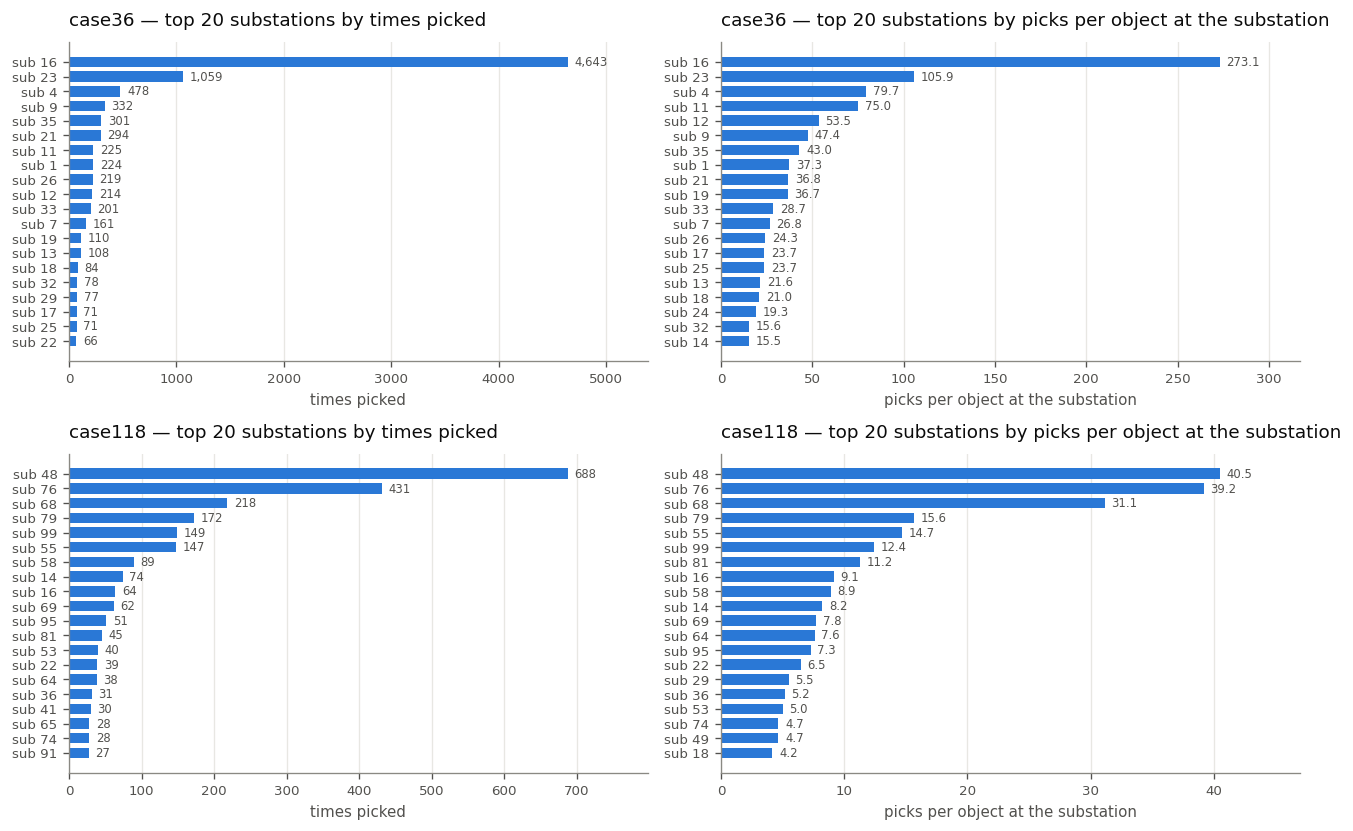

In [9]:
def substation_picks(grid: str) -> pd.DataFrame:
    """Per-substation pick counts, unique-action counts and size, sorted by picks."""
    table, sub_info = tables[grid], get_env(grid).action_space.sub_info
    grouped = table.groupby("sub").agg(picks=("picks", "sum"), actions=("encoded", "size"))
    grouped["n_objects"] = sub_info[grouped.index]
    grouped["picks_per_object"] = grouped["picks"] / grouped["n_objects"]
    return grouped.sort_values("picks", ascending=False)


sub_stats = {grid: substation_picks(grid) for grid in GRIDS}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
TOP_N = 20

for row, grid in enumerate(GRIDS):
    stats = sub_stats[grid]
    for col, (column, label) in enumerate([("picks", "times picked"),
                                           ("picks_per_object", "picks per object at the substation")]):
        ax = axes[row][col]
        shown = stats.sort_values(column, ascending=False).head(TOP_N).iloc[::-1]
        positions = np.arange(len(shown))
        # Single series -> one sequential hue; magnitude is already carried by bar length.
        ax.barh(positions, shown[column].values, height=0.72, color=SEQUENTIAL, edgecolor="none")
        ax.set_yticks(positions)
        ax.set_yticklabels([f"sub {i}" for i in shown.index])
        for y, value in zip(positions, shown[column].values):
            ax.annotate(f"{value:,.0f}" if column == "picks" else f"{value:,.1f}",
                        xy=(value, y), xytext=(4, 0), textcoords="offset points",
                        va="center", fontsize=7, color=INK2)
        ax.margins(x=0.16)
        style(ax, title=f"{grid} — top {TOP_N} substations by {label}", xlabel=label, grid_axis="x")

fig.tight_layout()

pd.DataFrame([
    {
        "grid": grid,
        "substations reached": len(sub_stats[grid]),
        "of total": len(get_env(grid).action_space.sub_info),
        "top-1 share of picks": f"{sub_stats[grid]['picks'].iloc[0] / sub_stats[grid]['picks'].sum():.1%}",
        "top-5 share of picks": f"{sub_stats[grid]['picks'].head(5).sum() / sub_stats[grid]['picks'].sum():.1%}",
        # Herfindahl index: 1/HHI is the "effective number" of substations in play.
        "effective substations (1/HHI)":
            round(1 / ((sub_stats[grid]["picks"] / sub_stats[grid]["picks"].sum()) ** 2).sum(), 1),
    }
    for grid in GRIDS
]).set_index("grid").T

## 6. Does the top-k spread across substations?

The handoff's acceptance criterion: the exported set *must not* be concentrated on one or two
substations. This is the check that decides whether a plain frequency top-k is usable at all.

substations largest substation share picks covered
grid    k                                                      
case36  50            19                    20.0%           26%
        100           23                    23.0%           34%
        200           26                    28.0%           44%
        400           27                    33.8%           55%
case118 50            19                    22.0%           14%
        100           29                    29.0%           22%
        200           38                    22.5%           34%
        400           45                    20.0%           49%

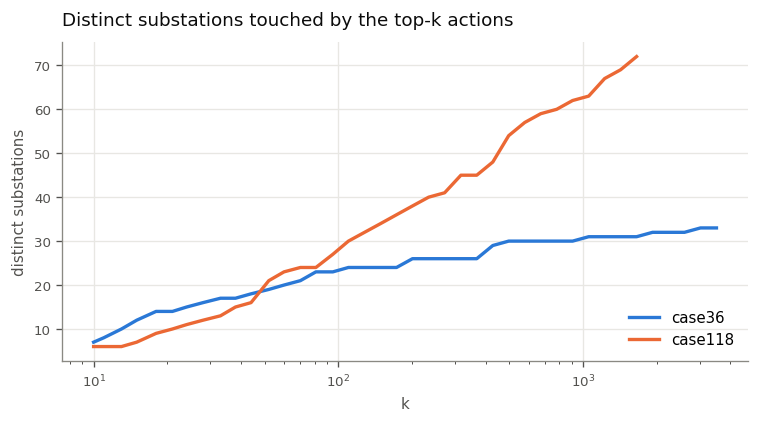

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ks = np.unique(np.geomspace(10, max(len(t) for t in tables.values()), 40).astype(int))

spread_rows = []
for grid, table in tables.items():
    xs = [k for k in ks if k <= len(table)]
    ys = [table.head(k)["sub"].nunique() for k in xs]
    ax.plot(xs, ys, color=SERIES[grid], label=grid)
    for k in (50, 100, 200, 400):
        if k <= len(table):
            head = table.head(k)
            spread_rows.append({
                "grid": grid, "k": k,
                "substations": head["sub"].nunique(),
                "largest substation share": f"{head['sub'].value_counts().iloc[0] / k:.1%}",
                "picks covered": f"{head['picks'].sum() / table['picks'].sum():.0%}",
            })
ax.set_xscale("log")
style(ax, title="Distinct substations touched by the top-k actions",
      xlabel="k", ylabel="distinct substations", grid_axis="both")
ax.legend(loc="lower right")
fig.tight_layout()

pd.DataFrame(spread_rows).set_index(["grid", "k"])

## 7. Is the ranking concentrated where we *made* it congested?

The teacher only ever sees congestion caused by the 10 `lines_to_attack`, so a substation's rank
may say more about that choice than about the grid. Splitting the picks by graph distance to an
attacked line separates the two. A set dominated by the attacked ring generalises poorly to
contingencies the agent will actually face.

In [11]:
def attack_rings(grid: str) -> dict[int, str]:
    """Label each substation `on attacked line`, `one hop away` or `farther`."""
    action_space = get_env(grid).action_space
    or_sub, ex_sub = action_space.line_or_to_subid, action_space.line_ex_to_subid

    attacked = {int(s) for line in LINES_TO_ATTACK[grid] for s in (or_sub[line], ex_sub[line])}
    neighbours = set()
    for line in range(action_space.n_line):
        origin, extremity = int(or_sub[line]), int(ex_sub[line])
        if origin in attacked:
            neighbours.add(extremity)
        if extremity in attacked:
            neighbours.add(origin)
    neighbours -= attacked

    labels = {}
    for sub in range(len(action_space.sub_info)):
        labels[sub] = ("on attacked line" if sub in attacked
                       else "one hop away" if sub in neighbours else "farther")
    return labels


ring_rows = []
for grid, table in tables.items():
    labels = attack_rings(grid)
    ring = table.assign(ring=table["sub"].map(labels))
    by_ring = ring.groupby("ring").agg(actions=("encoded", "size"), picks=("picks", "sum"))
    for name, row in by_ring.iterrows():
        ring_rows.append({
            "grid": grid, "ring": name,
            "unique actions": int(row["actions"]),
            "picks": int(row["picks"]),
            "share of picks": f"{row['picks'] / by_ring['picks'].sum():.1%}",
            "share of top-100": f"{(ring.head(100)['ring'] == name).mean():.0%}",
        })

pd.DataFrame(ring_rows).set_index(["grid", "ring"])

unique actions  picks share of picks  \
grid    ring                                                     
case36  farther                      106    854           9.2%   
        on attacked line            3176   6748          72.5%   
        one hop away                 229   1707          18.3%   
case118 farther                      408    682          24.1%   
        on attacked line            1031   1670          59.1%   
        one hop away                 282    474          16.8%   

                         share of top-100  
grid    ring                               
case36  farther                       19%  
        on attacked line              52%  
        one hop away                  29%  
case118 farther                       27%  
        on attacked line              58%  
        one hop away                  15%

## 8. Is the ranking stable, or still moving?

Two checks, both needed because case36's array is unfinished:

1. **Split-half agreement** — rank the even-numbered shards against the odd-numbered ones and
   compare the resulting top-k sets. Low overlap means the ranking is mostly sampling noise.
2. **Growth curve** — rank on the first *x*% of shards and measure overlap with the full ranking.
   If this is still climbing steeply at 100%, more shards will change the answer.

even-shard rows  top-k Jaccard (even vs odd)  top-k overlap count
grid    k                                                                     
case36  50              4744                        0.667                   40
        100             4744                        0.493                   66
        200             4744                        0.487                  131
        400             4744                        0.394                  226
case118 50              1467                        0.235                   19
        100             1467                        0.149                   26
        200             1467                        0.198                   66
        400             1467                        0.151                  105

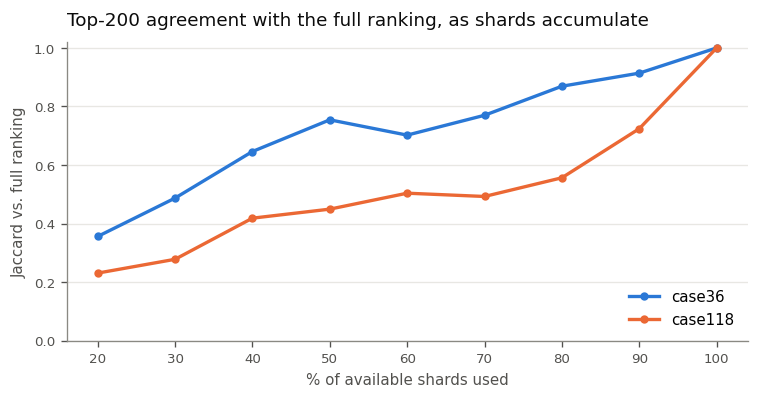

In [12]:
def jaccard(left: set, right: set) -> float:
    """Intersection over union — 1.0 when two top-k sets agree completely."""
    return len(left & right) / len(left | right) if (left or right) else float("nan")


split_rows, growth = [], {}
for grid, data in raw.items():
    good = data[data["good"]]
    even = frequency_curve(good[good["shard"] % 2 == 0])
    odd = frequency_curve(good[good["shard"] % 2 == 1])
    for k in (50, 100, 200, 400):
        split_rows.append({
            "grid": grid, "k": k,
            "even-shard rows": len(good[good["shard"] % 2 == 0]),
            "top-k Jaccard (even vs odd)": round(jaccard(set(even.index[:k]), set(odd.index[:k])), 3),
            "top-k overlap count": len(set(even.index[:k]) & set(odd.index[:k])),
        })

    shards = np.sort(good["shard"].unique())
    full = set(frequency_curve(good).index[:200])
    fractions = np.linspace(0.2, 1.0, 9)
    growth[grid] = (fractions, [
        jaccard(set(frequency_curve(good[good["shard"].isin(shards[:int(len(shards) * f)])]).index[:200]), full)
        for f in fractions
    ])

fig, ax = plt.subplots(figsize=(6.4, 3.4))
for grid, (fractions, overlaps) in growth.items():
    ax.plot(fractions * 100, overlaps, color=SERIES[grid], marker="o", markersize=4, label=grid)
style(ax, title="Top-200 agreement with the full ranking, as shards accumulate",
      xlabel="% of available shards used", ylabel="Jaccard vs. full ranking")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
fig.tight_layout()

pd.DataFrame(split_rows).set_index(["grid", "k"])

## 9. Frequency is not the only ranking available

Every row carries how much rho the action bought, and the aggregate knows how many distinct
shards picked it. Four candidate rankings:

| ranking | rationale | weakness |
|---|---|---|
| `picks` | what the tool does today | a state visited often in one chronic inflates it |
| `shard_support` | breadth — how many chronic groups found it useful | coarse, capped by shard count |
| `ri_sum` | total rho relief delivered = `picks x ri_mean` | still frequency-dominated |
| `ri_mean` | quality per use | rewards actions picked once, by luck |

If these disagree strongly, "top-k by frequency" is a weaker claim than it looks — especially on
case118, where the head of the frequency curve is only a handful of picks high.

In [13]:
from scipy.stats import spearmanr

RANKINGS = ["picks", "shard_support", "ri_sum", "ri_mean"]

correlation_frames = {}
for grid, table in tables.items():
    correlation = pd.DataFrame(index=RANKINGS, columns=RANKINGS, dtype=float)
    for a in RANKINGS:
        for b in RANKINGS:
            correlation.loc[a, b] = spearmanr(table[a], table[b]).statistic
    correlation_frames[grid] = correlation.round(2)

overlap_rows = []
for grid, table in tables.items():
    for k in (50, 100, 200):
        if k > len(table):
            continue
        by_picks = set(table.nlargest(k, "picks")["encoded"])
        for ranking in RANKINGS[1:]:
            alternative = set(table.nlargest(k, ranking)["encoded"])
            overlap_rows.append({
                "grid": grid, "k": k, "ranking": ranking,
                "shared with top-k by picks": len(by_picks & alternative),
                "as a share": f"{len(by_picks & alternative) / k:.0%}",
                "substations": table.nlargest(k, ranking)["sub"].nunique(),
            })

print("Spearman correlation between rankings")
for grid, correlation in correlation_frames.items():
    print(f"\n{grid}:")
    print(correlation.to_string())

pd.DataFrame(overlap_rows).set_index(["grid", "k", "ranking"])

Spearman correlation between rankings

case36:
               picks  shard_support  ri_sum  ri_mean
picks           1.00           1.00    0.71     0.08
shard_support   1.00           1.00    0.71     0.08
ri_sum          0.71           0.71    1.00     0.73
ri_mean         0.08           0.08    0.73     1.00

case118:
               picks  shard_support  ri_sum  ri_mean
picks           1.00           0.99    0.59     0.05
shard_support   0.99           1.00    0.57     0.04
ri_sum          0.59           0.57    1.00     0.82
ri_mean         0.05           0.04    0.82     1.00


shared with top-k by picks as a share  substations
grid    k   ranking                                                          
case36  50  shard_support                          48        96%           19
            ri_sum                                 42        84%           16
            ri_mean                                 0         0%            3
        100 shard_support                          98        98%           23
            ri_sum                                 84        84%           22
            ri_mean                                 0         0%            5
        200 shard_support                         197        98%           26
            ri_sum                                163        82%           24
            ri_mean                                 7         4%            7
case118 50  shard_support                          47        94%           21
            ri_sum                                 31        62%           18
            ri_mean                                 0         0%           13
        100 shard_support                          99        99%           29
            ri_sum                                 57        57%           25
            ri_mean                                 0         0%           23
        200 shard_support                         193        96%           37
            ri_sum                                126        63%           32
            ri_mean                                 9         4%           30

## 10. A substation-stratified alternative to a flat top-k

If §6 shows the flat top-k piling onto one substation, capping the number of actions taken *per
substation* buys spread at a small cost in covered picks. This is not what
`build_action_space.py aggregate` does today — it would need the exported list to be built here
and written with `export_action_space` directly, so treat it as a proposal to evaluate, not a
default.

In [14]:
def stratified_selection(table: pd.DataFrame, per_substation: int) -> pd.DataFrame:
    """Take the `per_substation` most-picked actions at each substation, then re-sort by picks."""
    capped = (table.sort_values("picks", ascending=False)
                   .groupby("sub", group_keys=False)
                   .head(per_substation))
    return capped.sort_values("picks", ascending=False).reset_index(drop=True)


rows = []
for grid, table in tables.items():
    total_picks = table["picks"].sum()
    for cap in (3, 5, 10, 20):
        selection = stratified_selection(table, cap)
        flat = table.head(len(selection))
        rows.append({
            "grid": grid, "cap per substation": cap,
            "k": len(selection),
            "substations": selection["sub"].nunique(),
            "largest substation share": f"{selection['sub'].value_counts().iloc[0] / len(selection):.1%}",
            "picks covered": f"{selection['picks'].sum() / total_picks:.0%}",
            "flat top-k covers": f"{flat['picks'].sum() / total_picks:.0%}",
            "flat top-k substations": flat["sub"].nunique(),
        })

pd.DataFrame(rows).set_index(["grid", "cap per substation"])

k  substations largest substation share  \
grid    cap per substation                                              
case36  3                    89           33                     3.4%   
        5                   124           33                     4.0%   
        10                  190           33                     5.3%   
        20                  287           33                     7.0%   
case118 3                   172           72                     1.7%   
        5                   251           72                     2.0%   
        10                  394           72                     2.5%   
        20                  587           72                     3.4%   

                           picks covered flat top-k covers  \
grid    cap per substation                                   
case36  3                            26%               33%   
        5                            31%               37%   
        10                           38%               43%   
        20                           44%               50%   
case118 3                            22%               31%   
        5                            29%               39%   
        10                           39%               49%   
        20                           51%               60%   

                            flat top-k substations  
grid    cap per substation                          
case36  3                                       23  
        5                                       24  
        10                                      25  
        20                                      26  
case118 3                                       36  
        5                                       41  
        10                                      45  
        20                                      57

## 11. Can two different base64 strings mean the same action?

`encode_action` is `base64(zlib(action._set_topo_vect, level=1))` — a pure function of the
topology vector — so **equal vectors always give equal strings** and there is no encoder
nondeterminism to clean up. The real question is *semantic* equivalence: two different vectors
describing the same physical topology. The one way that happens here is **busbar-label symmetry** —
at a substation, putting objects `{A}` on bus 1 and `{B}` on bus 2 is the same split as `{B}` on
bus 1 and `{A}` on bus 2.

The cell below canonicalises each action by relabelling busbars per substation in order of first
appearance, then counts how many encoded strings collapse together. It only relabels a substation
whose objects are *all* set: if some are left at 0 the labels are relative to whichever busbar the
untouched objects sit on, and permuting them would change the action's meaning.

In [15]:
def canonical_key(grid: str, encoded: str) -> bytes:
    """Busbar-label-invariant key for an action: relabel buses per fully-set substation."""
    pos2sub = position_to_substation(grid)
    topo_vect = decode_topo_vect(encoded).copy()
    for sub in np.unique(pos2sub[topo_vect > 0]):
        mask = pos2sub == sub
        if (topo_vect[mask] == 0).any():
            continue  # partially set: busbar labels are not free to permute
        configuration, mapping, next_label = topo_vect[mask].copy(), {}, 1
        for i, bus in enumerate(configuration):
            if bus <= 0:
                continue
            if bus not in mapping:
                mapping[bus] = next_label
                next_label += 1
            configuration[i] = mapping[bus]
        topo_vect[mask] = configuration
    return topo_vect.tobytes()


for grid, table in tables.items():
    pos2sub = position_to_substation(grid)
    vectors = {encoded: decode_topo_vect(encoded) for encoded in table["encoded"]}
    keys = {encoded: canonical_key(grid, encoded) for encoded in table["encoded"]}
    group_sizes = pd.Series(list(keys.values())).value_counts()

    print(f"{grid}:")
    print(f"  distinct bus values used across all actions: "
          f"{sorted({int(v) for vec in vectors.values() for v in vec})}")
    print(f"  substations touched per action: "
          f"{table['n_substations'].value_counts().to_dict()}")
    print(f"  actions leaving some object at the touched substation unset: {int((table['n_unset'] > 0).sum())}")
    print(f"  first object at the touched substation is on bus 1: "
          f"{sum(1 for enc, vec in vectors.items() for s in [np.unique(pos2sub[vec > 0])[0]] if vec[pos2sub == s][0] == 1)}"
          f"/{len(vectors)}")
    print(f"  unique encoded strings: {len(keys)}  ->  unique canonical keys: {group_sizes.size}")
    print(f"  canonical groups holding more than one string: {int((group_sizes > 1).sum())}\n")

case36:
  distinct bus values used across all actions: [0, 1, 2]
  substations touched per action: {1: 3511}
  actions leaving some object at the touched substation unset: 0
  first object at the touched substation is on bus 1: 3511/3511
  unique encoded strings: 3511  ->  unique canonical keys: 3511
  canonical groups holding more than one string: 0



case118:
  distinct bus values used across all actions: [0, 1, 2]
  substations touched per action: {1: 1721}
  actions leaving some object at the touched substation unset: 0
  first object at the touched substation is on bus 1: 1721/1721
  unique encoded strings: 1721  ->  unique canonical keys: 1721
  canonical groups holding more than one string: 0



## 12. "Reset to reference" actions

An action that sets every object at its substation to bus 1 *is* the reference (unsplit) topology.
These are legitimate — reached from a split state they merge the busbars back — but they behave
differently from the splitting actions around them, and there is exactly one per substation, so
they are worth seeing separately.

In [16]:
for grid, table in tables.items():
    reference = table[(table["n_on_bus2"] == 0) & (table["n_unset"] == 0)]
    print(f"{grid}: {len(reference)} reference-config actions, "
          f"{reference['picks'].sum()} picks ({reference['picks'].sum() / table['picks'].sum():.1%} of all), "
          f"best rank {int(reference['rank'].min()) if len(reference) else '-'}")
    print(reference.head(5)[["rank", "sub", "picks", "shard_support", "ri_mean"]].to_string(index=False), "\n")

case36: 29 reference-config actions, 1253 picks (13.5% of all), best rank 1
 rank  sub  picks  shard_support  ri_mean
    1    1    220            159 0.122312
    4   12    105             94 0.096961
    7   11     96             81 0.090610
    8   19     87             69 0.135839
    9    4     76             66 0.203596 

case118: 54 reference-config actions, 186 picks (6.6% of all), best rank 1
 rank  sub  picks  shard_support  ri_mean
    1   79     15             14 0.118560
    3   64     14             14 0.102004
    8   49     11              9 0.076676
   10   76     10             10 0.093064
   15   48      9              9 0.086222 



## 13. Do the teacher's actions live inside the curated RL2Grid space?

The configs currently point at `rl2grid_bus36-M_1` / `rl2grid_bus118-M_1`, and `..._M_4` is the
largest of each family. Those files store **`change_bus`** actions while the teacher exports
**`set_bus`**, so comparing them means converting: from the all-bus-1 reference (verified below),
a `change_bus` flips the flagged objects to bus 2.

Read the overlap **together with the two structural columns**, because the two grids' files are
not built the same way:

- `rl2grid_bus118-M_4` is a single-substation (unitary) space, directly comparable to the
  teacher's output.
- `rl2grid_bus36-M_4` is dominated by 2- and 3-substation *combinations*. The teacher only ever
  emits single-substation actions, so a low overlap there says the two spaces are different in
  kind, **not** that the teacher invented anything.

This cell also re-uses `canonical_key`'s busbar relabelling on the curated files, which is where
§11's question actually has a live instance: the teacher's own output has zero label-duplicates,
but a curated file may not.

A few entries in `rl2grid_bus118-M_4.json` name grid objects this environment does not have (e.g.
`load_23_20`) and cannot be built; they are counted and skipped. Both `M_1` files build cleanly,
so this does not affect what the configs point at today.

**This is the slowest cell in the notebook.** Set `RL2GRID_FILE` to the `..._M_1.json` files for a
quick pass.

In [17]:
RL2GRID_FILE = {"case36": "rl2grid_bus36-M_4.json", "case118": "rl2grid_bus118-M_4.json"}
RUN_RL2GRID_OVERLAP = True


def change_bus_key(grid: str, action, canonicalise: bool = True) -> bytes | None:
    """Set_bus key for a change_bus action, resolved against the all-bus-1 reference topology.

    With `canonicalise`, each touched substation is relabelled so its first object sits on bus 1 —
    the same convention the teacher's encoder already follows. Comparing the counts with and
    without it measures how many entries are busbar-label duplicates of each other.
    """
    pos2sub = position_to_substation(grid)
    changed = action._change_bus_vect
    if not changed.any():
        return None  # the empty (do-nothing) entry at index 0
    topo_vect = np.zeros(len(pos2sub), dtype=np.int32)
    for sub in np.unique(pos2sub[changed]):
        mask = pos2sub == sub
        configuration = np.where(changed[mask], 2, 1).astype(np.int32)
        if canonicalise and configuration[0] == 2:
            configuration = np.where(configuration == 2, 1, 2).astype(np.int32)
        topo_vect[mask] = configuration
    return topo_vect.tobytes()


def curated_summary(grid: str, path: Path) -> dict:
    """Canonical keys for a curated action-space JSON, plus its structure and duplicate counts."""
    env = get_env(grid)
    pos2sub = position_to_substation(grid)
    with open(path, "rt", encoding="utf-8") as handle:
        dicts = json.load(handle)

    canonical, verbatim, substation_counts, unbuildable = [], set(), [], 0
    for action_dict in dicts:
        try:
            action = env.action_space(action_dict)
        except Exception:
            unbuildable += 1  # stale entry naming a load/line this environment does not have
            continue
        key = change_bus_key(grid, action)
        if key is None:
            continue
        canonical.append(key)
        verbatim.add(change_bus_key(grid, action, canonicalise=False))
        substation_counts.append(len(np.unique(pos2sub[action._change_bus_vect])))

    return {
        "entries": len(dicts),
        "unbuildable": unbuildable,
        "verbatim_keys": len(verbatim),
        "canonical_keys": len(set(canonical)),
        "substations_touched": pd.Series(substation_counts).value_counts().sort_index().to_dict(),
        "keys": set(canonical),
    }


if RUN_RL2GRID_OVERLAP:
    for grid, table in tables.items():
        reference_topology = get_env(grid).reset().topo_vect
        summary = curated_summary(grid, ACTION_SPACE_DIRS[grid] / RL2GRID_FILE[grid])
        teacher = {canonical_key(grid, encoded) for encoded in table["encoded"]}
        curated = summary["keys"]
        label_duplicates = summary["verbatim_keys"] - summary["canonical_keys"]

        print(f"{grid} vs {RL2GRID_FILE[grid]}:")
        print(f"  reference topology is all bus 1: {bool((reference_topology == 1).all())}")
        print(f"  entries: {summary['entries']}  ({summary['unbuildable']} unbuildable, skipped)")
        print(f"  substations touched per entry: {summary['substations_touched']}")
        print(f"  distinct verbatim: {summary['verbatim_keys']}  ->  after busbar relabelling: "
              f"{summary['canonical_keys']}  ({label_duplicates} label-duplicates, "
              f"{label_duplicates / max(summary['verbatim_keys'], 1):.1%})")
        print(f"  teacher actions: {len(teacher)}  (all single-substation)")
        print(f"  teacher actions present in this space: {len(teacher & curated)}"
              f" ({len(teacher & curated) / len(teacher):.1%})")
        print(f"  share of this space the teacher ever picked: "
              f"{len(teacher & curated) / len(curated):.2%}\n")

case36 vs rl2grid_bus36-M_4.json:
  reference topology is all bus 1: True
  entries: 66978  (0 unbuildable, skipped)
  substations touched per entry: {1: 654, 2: 10427, 3: 55335}
  distinct verbatim: 66416  ->  after busbar relabelling: 35369  (31047 label-duplicates, 46.7%)
  teacher actions: 3511  (all single-substation)
  teacher actions present in this space: 202 (5.8%)
  share of this space the teacher ever picked: 0.57%



case118 vs rl2grid_bus118-M_4.json:
  reference topology is all bus 1: True
  entries: 72461  (25 unbuildable, skipped)
  substations touched per entry: {1: 72249}
  distinct verbatim: 72249  ->  after busbar relabelling: 72249  (0 label-duplicates, 0.0%)
  teacher actions: 1721  (all single-substation)
  teacher actions present in this space: 1667 (96.9%)
  share of this space the teacher ever picked: 2.31%



## 14. Pick `k` and export

Fill in `CHOSEN_K` from what the cells above show, then run the printed command. `aggregate`
re-derives the same ranking from the shard CSVs and runs `verify_round_trip` before writing, so
the export is the authoritative artifact — this notebook only decides the number.

If §6 and §10 say a flat top-k is too concentrated, the alternative is to build the list here with
`stratified_selection` and call `export_action_space` directly; the commented block shows how.

In [18]:
CHOSEN_K = {"case36": None, "case118": None}  # <- fill in

SPLIT_DIRS = {"case36": "l2rpn_wcci_2020", "case118": "l2rpn_wcci_2022"}
for grid, k in CHOSEN_K.items():
    if k is None:
        print(f"{grid}: k not chosen yet")
        continue
    head = tables[grid].head(k)
    print(f"{grid}: k={k} -> {head['sub'].nunique()} substations, "
          f"{head['picks'].sum() / tables[grid]['picks'].sum():.0%} of picks covered")
    print(f"  PYTHONPATH=$(pwd)/src python experiments/build_action_space.py aggregate \\\n"
          f"      --grid {grid} \\\n"
          f"      --experience \"results/teacher/{'2026_09_17_teacher_n1_case36' if grid == 'case36' else '2026_09_18_teacher_n1_case118'}/shard_*.csv\" \\\n"
          f"      --top-k {k} \\\n"
          f"      --out data/action_spaces/{SPLIT_DIRS[grid]}/teacher_n1_k{k}.json\n")

# Stratified alternative, if a flat top-k is too concentrated:
#
# from action_space_generation.export import export_action_space, verify_round_trip
# grid, cap = "case36", 10
# selection = stratified_selection(tables[grid], cap)
# env = get_env(grid)
# actions = [env.action_space({"set_bus": {"substations_id": [(int(row["sub"]), decode_topo_vect(row["encoded"])[position_to_substation(grid) == row["sub"]].tolist())]}})
#            for _, row in selection.iterrows()]
# assert verify_round_trip(actions, env)
# export_action_space(actions, ROOT / "data" / "action_spaces" / SPLIT_DIRS[grid] / f"teacher_n1_strat{cap}.json")

case36: k not chosen yet
case118: k not chosen yet


In [19]:
for env in _ENV_CACHE.values():
    env.close()
_ENV_CACHE.clear()
print("environments closed")

environments closed
